In [2]:
import json
import itertools

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.args import DefaultArgumentParser

In [4]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
]

args = DefaultArgumentParser.parse(args=string_args)

In [5]:
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449.0
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504.0
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756.0
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138.0
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751.0
...,...,...,...,...,...,...
1709424000,62039.90,63330.90,61339.50,63178.50,200312.503,22965.0
1709510400,63178.50,68600.00,62299.00,68296.40,632882.144,58113.0
1709596800,68296.50,69350.00,59112.00,63747.40,1053025.132,92467.0


In [16]:
df = sdf.copy()
df["roc"] = df.close / df.open - 1
df["csroc"] = np.cumsum(df.roc)
df["scsroc"] = df.csroc.rolling(window=21, min_periods=1, center=True).mean()
df["dif"] = df.scsroc.diff()

df["trend"] = 0.0075 <= np.abs(df.dif)
print(df.trend.value_counts() / len(df))

df

trend
False    0.686769
True     0.313231
Name: count, dtype: float64


,open,high,low,close,volume,trade,roc,csroc,scsroc,dif,trend
timestamp,,,,,,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449.0,-0.043663,-0.043663,-0.031910,NaN,False
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504.0,0.014207,-0.029456,-0.031442,0.000468,False
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756.0,0.002093,-0.027362,-0.031242,0.000200,False
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138.0,-0.019154,-0.046516,-0.027648,0.003594,False
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751.0,0.030311,-0.016205,-0.024562,0.003086,False
...,...,...,...,...,...,...,...,...,...,...,...
1709424000,62039.90,63330.90,61339.50,63178.50,200312.503,22965.0,0.018353,3.036243,2.970805,0.008697,True
1709510400,63178.50,68600.00,62299.00,68296.40,632882.144,58113.0,0.081007,3.117250,2.981517,0.010712,True
1709596800,68296.50,69350.00,59112.00,63747.40,1053025.132,92467.0,-0.066608,3.050641,2.994693,0.013176,True


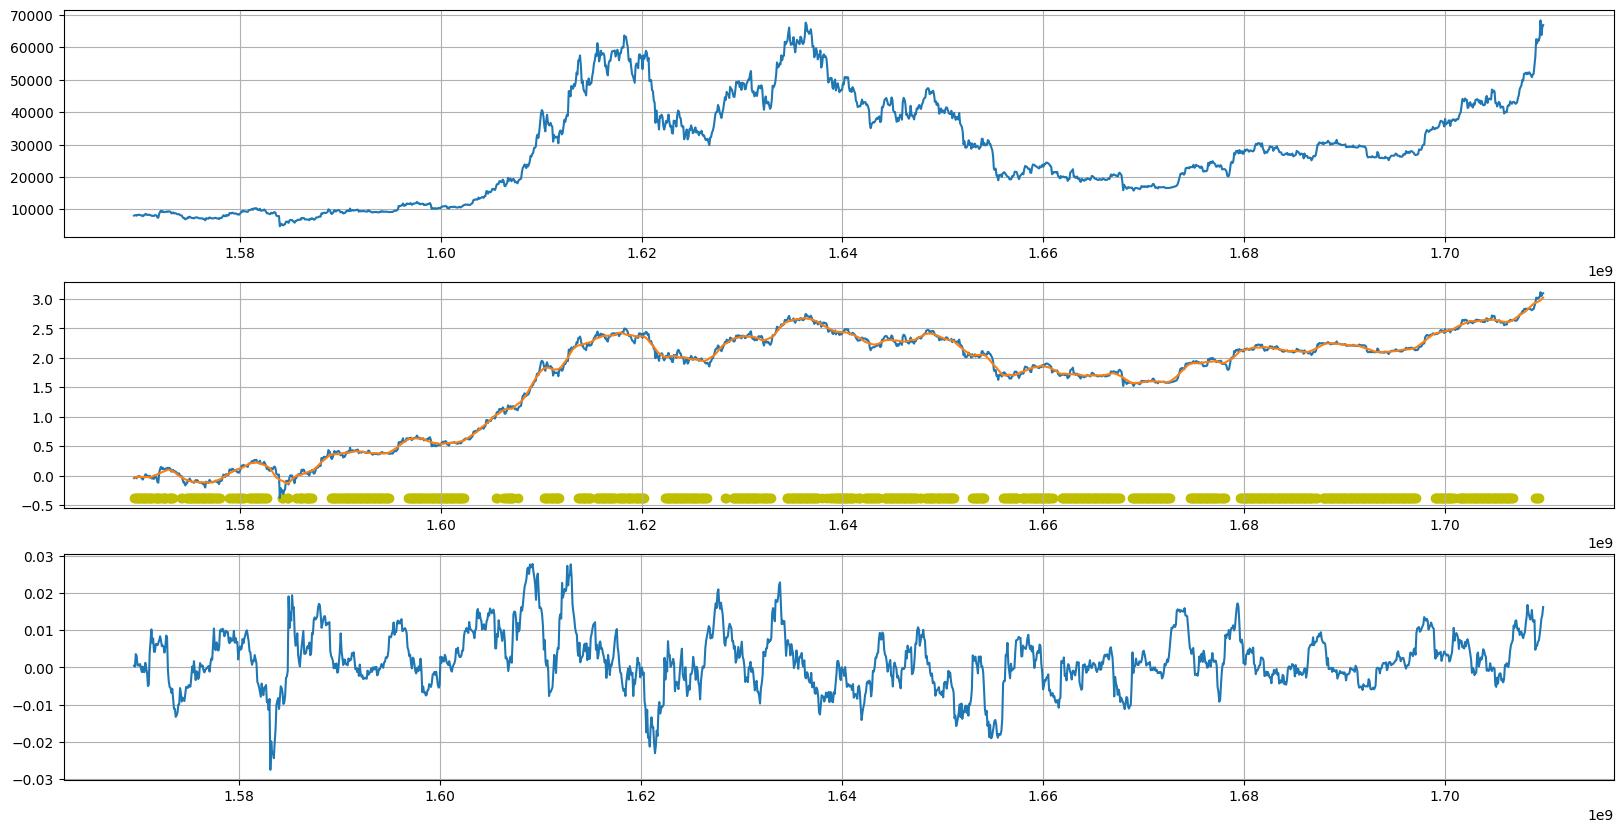

In [18]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

axs[0].plot(df.close)
axs[0].grid()

x = df[~df.trend].index.to_list()
y = [df.csroc.min()] * len(x)

axs[1].plot(df.csroc)
axs[1].plot(df.scsroc)
axs[1].scatter(x=x, y=y, color="y")
axs[1].grid()

axs[2].plot(df.dif)
axs[2].grid()